### 12. Validação Externa

In [1]:
# Bibliotecas necessárias
import sys
import os

sys.path.append(
    os.path.abspath("../features")
)

import pandas as pd
import joblib

from feature_extractor_v1 import extract_features

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [2]:
# features url 
url_features = [
    'NumDots',
    'SubdomainLevel',
    'PathLevel',
    'UrlLength',
    'NumDash',
    'NumDashInHostname',
    'AtSymbol',
    'TildeSymbol',
    'NumUnderscore',
    'NumPercent',
    'NumQueryComponents',
    'NumAmpersand',
    'NumHash',
    'NumNumericChars',
    'NoHttps',
    'IpAddress',
    'DomainInSubdomains',
    'DomainInPaths',
    'HostnameLength',
    'PathLength',
    'QueryLength',
    'DoubleSlashInPath'
]

In [3]:
# carregando o database construído no building db
df_final = pd.read_csv("../datasets/interim/df_built.csv")

In [4]:
features = df_final["url"].apply(extract_features)

In [5]:
X_external = pd.DataFrame(
    features.tolist()
)

In [6]:
rf_model = joblib.load(
    "../models/url_v1/random_forest_url.pkl"
)

In [7]:
y_pred = rf_model.predict(
    X_external
)

In [8]:
X_external.shape

(115934, 22)

In [9]:
# Distribuição de label
df_final["label"].value_counts()

label
1    57967
0    57967
Name: count, dtype: int64

In [10]:
# Métricas de Performance
y_true = df_final["label"]

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))

Accuracy : 0.5933462142253351
Precision: 0.6355189340813464
Recall   : 0.4377490641226905
F1 Score : 0.5184125849124062


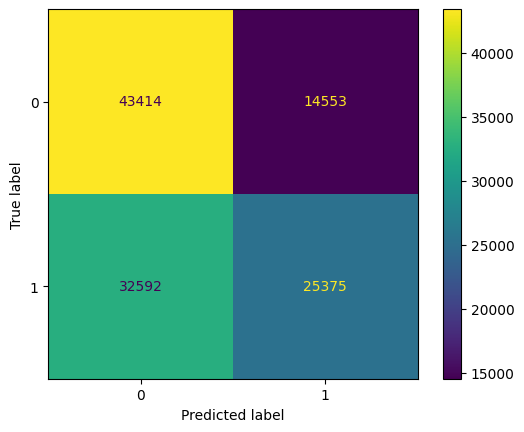

In [11]:
# Matriz de confusão

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

In [12]:
proba = rf_model.predict_proba(X_external)

df_final["prob_legit"] = proba[:,0]
df_final["prob_phishing"] = proba[:,1]
df_final["prediction"] = y_pred

In [13]:
false_negatives = df_final[
    (df_final["label"] == 1) &
    (df_final["prediction"] == 0)
]

false_negatives[
    ["url", "source"]
].head(20)

,url,source
2,http://63179679.satgrjtxcvdv.org.cn/amagc,phishingdb
6,http://annetteworkpublicrelations.com/2/04.php...,phishingdb
7,http://about.whateveramazonhelp.monster/signin...,phishingdb
10,http://dhles-co.cc/dhl-za,phishingdb
13,http://4tyea75.wixsite.com/my-site,phishingdb
14,https://www-flrstherizen.top,phishingdb
15,http://acessonline.digital/resource,phishingdb
19,http://actionproductions.com.au/docusign,phishingdb
24,http://analysis-guidance-notes.vercel.app,phishingdb
38,http://365accountonlinelogin.com,phishingdb


In [14]:
false_positives = df_final[
    (df_final["label"] == 0) &
    (df_final["prediction"] == 1)
]

false_positives[
    ["url", "source"]
].head(20)

,url,source
11,en.wikipedia.org/wiki/Organic_food,kaggle_benign
20,palac-sztuki.krakow.pl/en/tpsp/historia/,kaggle_benign
21,freescale.com/webapp/sps/site/overview.jsp?cod...,kaggle_benign
33,militaryjobhunts.com/overseas_jobs/c_guard.html,kaggle_benign
43,blingcheese.com/graphics/1/kelly+blatz.htm,kaggle_benign
45,linkedin.com/in/katiegmoore,kaggle_benign
46,pipl.com/directory/name/Beaubien/Raymond,kaggle_benign
51,economicexpert.com/a/Soviet:Union.htm,kaggle_benign
52,freepages.genealogy.rootsweb.ancestry.com/~cot...,kaggle_benign
63,paypal.com-us.cgi-bin-webscr-cmd.login-submit-...,kaggle_benign


In [15]:
for source in df_final["source"].unique():

    subset = df_final[
        df_final["source"] == source
    ]

    score = accuracy_score(
        subset["label"],
        subset["prediction"]
    )

    print(
        f"{source}: {score:.4f}"
    )

phishingdb: 0.4377
kaggle_benign: 0.7489


### Validação Externa do Modelo

Após o treinamento do modelo Random Forest utilizando apenas atributos extraídos da URL, foi realizada uma validação externa com o objetivo de avaliar sua capacidade de generalização em dados provenientes de fontes diferentes daquelas utilizadas durante o treinamento.

Para isso, foi construído um conjunto de dados externo composto por 115.934 URLs, distribuídas de forma balanceada entre URLs legítimas e URLs de phishing (57.967 registros para cada classe). As URLs maliciosas foram obtidas a partir das bases Phishing.Database e Malicious URLs Dataset, enquanto as URLs legítimas foram obtidas do conjunto benigno disponibilizado no Kaggle. Em seguida, foram extraídas as mesmas 22 características estruturais de URL utilizadas durante o treinamento do modelo original.

Os resultados obtidos foram os seguintes:

| Métrica   | Valor  |
| --------- | ------ |
| Accuracy  | 59,33% |
| Precision | 63,55% |
| Recall    | 43,77% |
| F1-Score  | 51,84% |

A matriz de confusão gerada durante a validação externa é apresentada a seguir:

|          | Predito Legítimo | Predito Phishing |
| -------- | ---------------: | ---------------: |
| Legítimo |           43.414 |           14.553 |
| Phishing |           32.592 |           25.375 |

Observa-se que o modelo conseguiu identificar corretamente 25.375 URLs de phishing, porém classificou incorretamente 32.592 URLs maliciosas como legítimas. Esse comportamento é refletido no valor de Recall de 43,77%, indicando que mais da metade dos ataques presentes no conjunto externo não foi detectada.

A análise dos falsos negativos revelou diversos exemplos de URLs de phishing que apresentavam estruturas aparentemente legítimas, muitas delas hospedadas em serviços populares ou utilizando domínios que simulavam marcas conhecidas. Exemplos observados incluem URLs associadas a plataformas como Wix, Vercel, Netlify e páginas que faziam referência a serviços amplamente utilizados, como Amazon, DHL e DocuSign. Embora essas URLs fossem efetivamente maliciosas, suas características estruturais não foram suficientes para que o modelo as distinguisse de URLs legítimas.

Por outro lado, a análise dos falsos positivos mostrou que algumas URLs legítimas foram classificadas como phishing devido à presença de padrões frequentemente associados a ataques, como caminhos extensos, múltiplos níveis de diretórios, parâmetros de consulta e termos potencialmente suspeitos. Entre os exemplos observados encontram-se páginas da Wikipedia, LinkedIn e outros sites legítimos com estruturas complexas de URL.

Os resultados obtidos indicam que o modelo apresentou desempenho significativamente inferior quando exposto a dados provenientes de fontes diferentes daquelas utilizadas durante o treinamento. Esse comportamento sugere uma limitação na capacidade de generalização do modelo baseado exclusivamente em atributos de URL.

Além disso, os resultados evidenciam que, embora características estruturais da URL sejam capazes de capturar determinados padrões associados a ataques de phishing, elas podem não ser suficientes para representar adequadamente a diversidade de técnicas empregadas em campanhas modernas. Muitos ataques atuais utilizam domínios aparentemente legítimos, serviços de hospedagem amplamente conhecidos e URLs com estruturas semelhantes às encontradas em sites legítimos, dificultando a detecção baseada exclusivamente em características sintáticas.

Dessa forma, a validação externa demonstrou que o modelo treinado com apenas atributos de URL possui limitações importantes quando aplicado a cenários reais e dinâmicos, reforçando a necessidade de explorar estratégias complementares, como a ampliação da base de treinamento com fontes mais recentes ou a incorporação de novas características capazes de representar melhor o comportamento dos sites analisados.
